Praktikum  Kecerdasan Buatan Week 5 Sesi 3

Topik : Hierarchical Clustering

Nama : Gracelita Hutauruk

Nim  : 42324012

Prodi : D3 Teknologi Informasi

Hierarchical Clustering adalah salah satu metode klasterisasi yang mengelompokkan data ke dalam bentuk hierarki. Metode ini sering digunakan untuk mengidentifikasi kelompok data yang mirip dengan menggabungkan atau memisahkan klaster secara bertahap. Pada percobaan pertama, akan digunakan dataset sederhana untuk mempermudah pemahaman.

Kode Program Dataset Sederhana

=== Distance Matrix (Euclidean) ===
          a         b         c         d         e         f
a  0.000000  0.707107  5.656854  3.605551  4.242641  3.201562
b  0.707107  0.000000  4.949747  2.915476  3.535534  2.500000
c  5.656854  4.949747  0.000000  2.236068  1.414214  2.500000
d  3.605551  2.915476  2.236068  0.000000  1.000000  0.500000
e  4.242641  3.535534  1.414214  1.000000  0.000000  1.118034
f  3.201562  2.500000  2.500000  0.500000  1.118034  0.000000


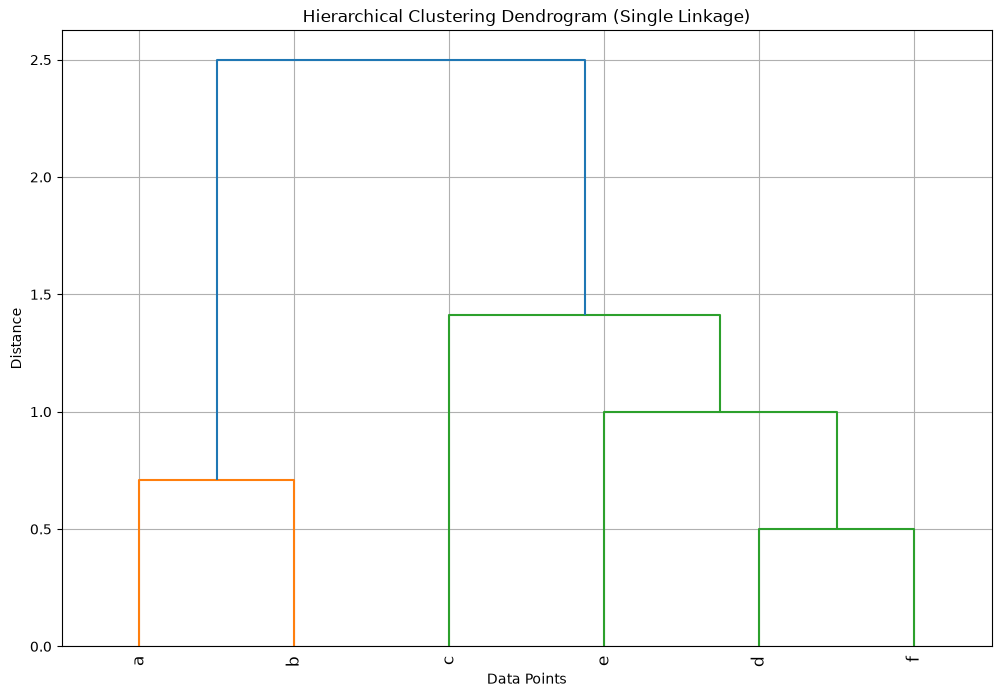

In [1]:
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt

# 1. Dataset sederhana
data = np.array([
    [1.0, 1.0], # a
    [1.5, 1.5], # b
    [5.0, 5.0], # c
    [3.0, 4.0], # d
    [4.0, 4.0], # e
    [3.0, 3.5]  # f
])

# 2. Hitung Distance Matrix (Euclidean Distance)
distance_matrix = pdist(data, metric='euclidean')
distance_df = pd.DataFrame(
    squareform(distance_matrix),
    columns=['a', 'b', 'c', 'd', 'e', 'f'],
    index=['a', 'b', 'c', 'd', 'e', 'f']
)

# 3. Tampilkan Distance Matrix
print("=== Distance Matrix (Euclidean) ===")
print(distance_df)

# 4. Hierarchical Clustering (Single Linkage)
linked = linkage(data, method='single')

# 5. Plot Dendrogram
plt.figure(figsize=(12, 8))
plt.title("Hierarchical Clustering Dendrogram (Single Linkage)")
dendrogram(
    linked, 
    labels=['a', 'b', 'c', 'd', 'e', 'f'], 
    leaf_rotation=90
)
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.grid(True)
plt.show()

Pada percobaan kedua, akan digunakan dataset Mall Customers untuk mengelompokkan pelanggan berdasarkan dua fitur penting, yaitu Annual Income dan Spending Score. Tujuan dari percobaan ini adalah mengelompokkan pelanggan ke dalam klaster yang serupa berdasarkan pola pengeluaran mereka.

Kode Program Dataset Mall Customers

In [4]:
# 1. Membaca dataset
import pandas as pd

df = pd.read_csv('Mall_Customers.csv')
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


Penjelasan :

import pandas as pd: Memanggil pustaka Pandas yang berfungsi untuk memuat, memanipulasi, dan menganalisis data terstruktur dalam bentuk DataFrame.  

 df = pd.read_csv("/content/Mall_Customers.csv"): Membaca file berkas CSV bernama Mall_Customers.csv dari jalur penyimpanan internal dan menyimpannya ke dalam variabel DataFrame bernama df.   

df.head(): Menampilkan 5 baris pertama data dari variabel df untuk memeriksa struktur tabel dan kolom yang ada. 



Pada bagian ini, langkah awal dilakukan dengan mengimpor pustaka Pandas yang diperlukan untuk pengelolaan data. Kode ini bertugas untuk membaca file data pelanggan Mall Customers yang berformat CSV dan memuatnya ke dalam struktur tabel DataFrame. Setelah data berhasil dimuat, fungsi head() dipanggil untuk memverifikasi apakah struktur data seperti kolom CustomerID, Genre, Age, Annual Income (k$), dan Spending Score (1-100) sudah terbaca dengan benar. 

Kode Program

In [5]:
# 2. Mengambil fitur Annual Income (kolom index 3) dan Spending Score (kolom index 4)
x = df.iloc[:, [3, 4]].values

Penjelasan :

df.iloc[:, [3, 4]]: Mengambil seluruh baris data (:) khusus pada kolom indeks ke-3 yaitu Annual Income (k$) dan indeks ke-4 yaitu Spending Score (1-100).

values: Mengubah data dari bentuk objek DataFrame menjadi array matriks dua dimensi NumPy.   

x = ...: Menyimpan hasil array matriks fitur tersebut ke dalam variabel x.  


Bagian ini bertujuan untuk menyeleksi variabel atau fitur tertentu dari dataset yang akan digunakan sebagai masukan dalam proses pemodelan klaster. Dengan menggunakan indeks iloc, program mengambil kolom pendapatan tahunan (Annual Income) dan skor pengeluaran (Spending Score) dari seluruh sampel pelanggan. Hasil ekstraksi ini kemudian diubah menjadi array dua dimensi dan disimpan dalam variabel x agar siap diproses pada tahapan analisis selanjutnya.   

Kode Program

In [6]:
from sklearn.preprocessing import StandardScaler

data_scaler = StandardScaler()
scaled_data = data_scaler.fit_transform(x)
scaled_data.shape

(200, 2)

Penjelasan :

from sklearn.preprocessing import StandardScaler: Mengimpor modul StandardScaler dari pustaka Scikit-Learn untuk keperluan normalisasi data.   

data_scaler = StandardScaler(): Menginisialisasi objek transformasi penyesuaian skala variabel.   

scaled_data = data_scaler.fit_transform(x): Menghitung nilai rata-rata dan standar deviasi dari matriks x, lalu mengubah setiap nilainya agar berpusat pada rata-rata 0 dan varians 1. 

scaled_data.shape: Menampilkan dimensi atau ukuran dari matriks hasil standarisasi.   

Tahap ini berfokus pada pra-pemrosesan data dengan cara melakukan standarisasi terhadap fitur yang telah dipilih. Metode StandardScaler menyamakan skala antar fitur agar perbedaan rentang angka pada variabel tidak mendominasi perhitungan jarak. Setelah transformasi dilakukan, perintah scaled_data.shape dijalankan untuk memastikan bahwa matriks hasil transformasi memiliki bentuk dimensi (200, 2) yang menandakan terdapat 200 data baris pelanggan dan 2 kolom fitur yang siap diproses.   

Kode Program

In [7]:
from scipy.cluster.hierarchy import linkage, dendrogram

clustering = linkage(scaled_data, method="complete", metric="euclidean")

Penjelasan :

from scipy.cluster.hierarchy import linkage, dendrogram: Mengimpor fungsi linkage untuk membentuk pengelompokan hierarki dan dendrogram untuk visualisasi pohon.   

method="complete": Menentukan metode penggabungan Complete Linkage, yaitu menggunakan jarak maksimum antar titik data dalam dua klaster.   

metric="euclidean": Menggunakan rumus jarak Euclidean untuk mengukur tingkat kemiripan antar titik data.   

clustering = linkage(...): Menyimpan matriks gabungan hierarki klaster ke dalam variabel clustering.  

Pada sel ini dilakukan proses utama pembentukan Hierarchical Clustering menggunakan fungsi linkage dari SciPy. Algoritma memproses data pelanggan terstandarisasi dengan menggunakan metode Complete Linkage dan jarak Euclidean. Pendekatan ini menghitung jarak maksimum antar pasangan data untuk memutuskan penggabungan tiap kelompok secara bertahap dari bawah ke atas hingga seluruh data terhubung dalam satu hierarki utama.


Kode Program

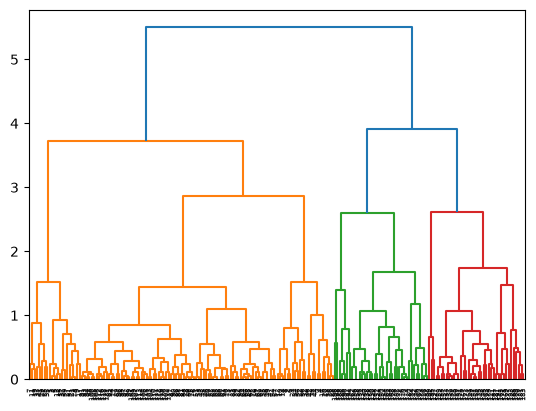

In [8]:
import matplotlib.pyplot as plt

dendrogram(clustering)
plt.show()

Penjelasan :


import matplotlib.pyplot as plt: Mengimpor pustaka Matplotlib untuk membuat visualisasi grafik.  

dendrogram(clustering): Membuat struktur grafik diagram pohon berdasarkan hasil perhitungan hierarki dari variabel clustering.

plt.show(): Menampilkan jendela grafik dendrogram ke layar.   

Bagian akhir ini berfungsi untuk menampilkan hasil analisis klasterisasi dalam bentuk visualisasi grafik dendrogram. Dengan memanggil fungsi dendrogram(), hierarki penggabungan data dipetakan menjadi bentuk diagram pohon yang memperlihatkan bagaimana 200 sampel pelanggan saling terhubung. Berdasarkan pola dendrogram yang terbentuk, data pelanggan dapat terbagi menjadi tiga kelompok utama (oranye, hijau, dan merah) yang menggambarkan segmentasi pola pengeluaran pelanggan. 

Dendrogram ini membagi data pelanggan menjadi tiga kelompok utama: oranye, hijau, dan merah. Pembagian ini membantu mengidentifikasi segmentasi pelanggan yang dapat digunakan untuk strategi pemasaran yang lebih tepat sasaran. Misalnya pelanggan dengan pengeluaran rendah, sedang, dan tinggi, sehingga bisnis bisa memberikan penawaran yang lebih sesuai untuk setiap kelompok.

Tugas!!


Pada percobaan pertama dengan dataset sederhana, bandingkan hasil plot dendrogram single linkage dengan complete linkage dan average linkage

Kode Program Tugas

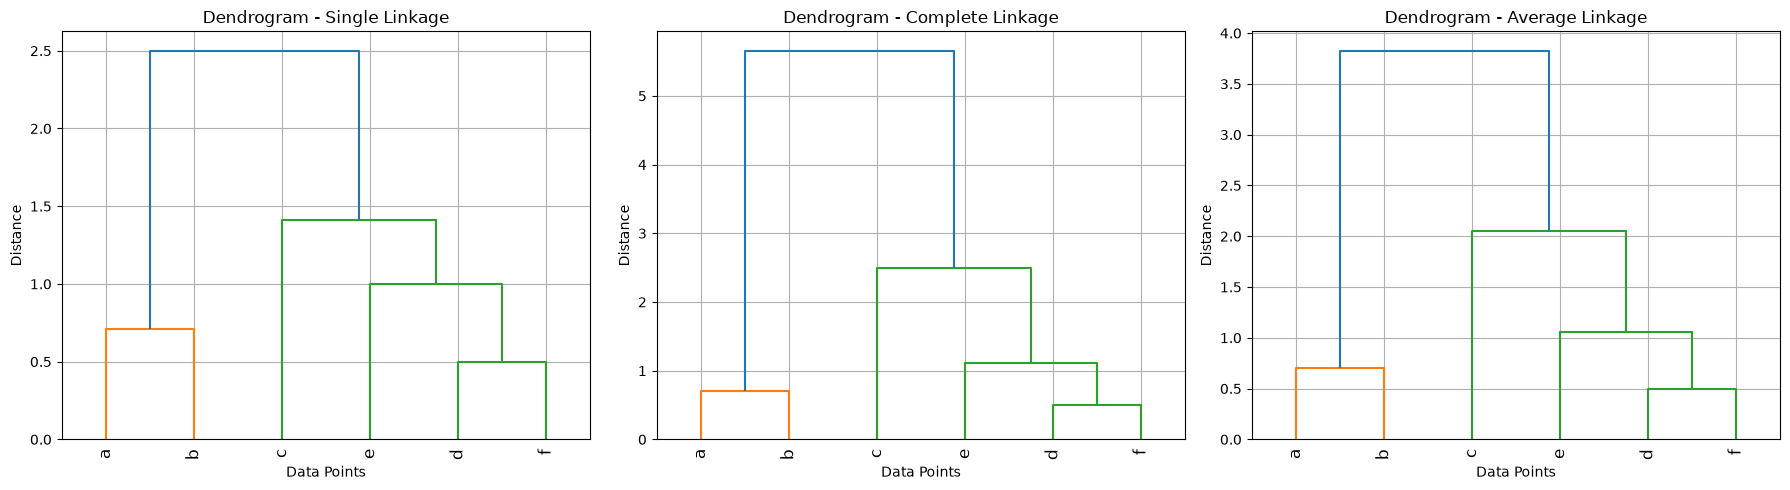

In [9]:
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

# Dataset sederhana sesuai percobaan pertama
data = np.array([
    [1.0, 1.0], # a
    [1.5, 1.5], # b
    [5.0, 5.0], # c
    [3.0, 4.0], # d
    [4.0, 4.0], # e
    [3.0, 3.5]  # f
])

labels = ['a', 'b', 'c', 'd', 'e', 'f']

# Tiga metode linkage yang dibandingkan
methods = ['single', 'complete', 'average']

# Membuat subplot untuk membandingkan 3 dendrogram
plt.figure(figsize=(18, 5))

for i, method in enumerate(methods, 1):
    linked = linkage(data, method=method, metric='euclidean')
    
    plt.subplot(1, 3, i)
    dendrogram(linked, labels=labels, leaf_rotation=90)
    plt.title(f"Dendrogram - {method.capitalize()} Linkage")
    plt.xlabel("Data Points")
    plt.ylabel("Distance")
    plt.grid(True)

plt.tight_layout()
plt.show()

Penjelasan  :

Bagian 1: Inisialisasi Data dan LibraryPenjelasan

import numpy as np: Memanggil library NumPy untuk mengolah data dalam bentuk array matriks 2D.   

import pandas as pd: Memanggil library Pandas untuk mendukung pengolahan struktur data.   

from scipy.cluster.hierarchy import linkage, dendrogram: Mengimpor fungsi linkage untuk proses pengelompokan dan dendrogram untuk merancang grafik pohon hierarki.  

import matplotlib.pyplot as plt: Memanggil modul Pyplot dari Matplotlib untuk menampilkan visualisasi grafik.   

data = np.array(...): Mendefinisikan 6 titik data sederhana ($a, b, c, d, e, f$) dengan koordinat 2 dimensi sesuai percobaan pertama modul.   

labels = ['a', 'b', 'c', 'd', 'e', 'f']: Membuat daftar label nama untuk setiap titik data agar mempermudah pembacaan pada grafik dendrogram.   


Pada tahap pertama ini, seluruh pustaka yang dibutuhkan dipanggil ke dalam lingkungan kerja. Selanjutnya, dataset sederhana yang terdiri dari 6 titik koordinat dua dimensi didefinisikan menggunakan array NumPy. Penyiapan label string dari 'a' hingga 'f' juga dilakukan agar titik-titik data tersebut dapat teridentifikasi secara jelas pada sumbu horizontal dendrogram.  



Penjelasan  :


 Bagian 2: Implementasi Single LinkagePenjelasan 

linked_single = linkage(data, method='single', metric='euclidean'): Menerapkan pengelompokan hierarki dengan metode Single Linkage berdasarkan jarak Euclidean.   

plt.figure(figsize=(8, 5)): Mengatur ukuran canvas grafik menjadi lebar 8 inci dan tinggi 5 inci.   

plt.title("Dendrogram - Single Linkage"): Memberikan judul grafik dendrogram.   dendrogram(linked_single, labels=labels, 

leaf_rotation=90): Memetakan struktur klaster ke dalam grafik dengan posisi label diputar 90 derajat.   

plt.xlabel("Data Points") & plt.ylabel("Distance"): Memberikan label keterangan pada sumbu X (titik data) dan sumbu Y (jarak).  
 
plt.grid(True) & plt.show(): Menampilkan garis kisi latar belakang dan memunculkan grafik ke layar.   


Bagian ini memproses dataset menggunakan metode Single Linkage, yaitu metode yang menghitung jarak antar klaster berdasarkan pasangan titik terdekat (jarak minimum). Setelah matriks hierarki terbentuk, pustaka Matplotlib digunakan untuk mengonstruksi dan menampilkan gambar dendrogram. Visualisasi ini menunjukkan penggabungan titik secara bertahap berdasarkan jarak terpendek antar anggota klaster. 

Penjelasan : 

Bagian 3: Implementasi Complete LinkagePenjelasan 

linked_complete = linkage(data, method='complete', metric='euclidean'): Menghitung pengelompokan hierarki menggunakan metode Complete Linkage berbasis jarak Euclidean.   

dendrogram(linked_complete, labels=labels, leaf_rotation=90): Membentuk visualisasi grafik dendrogram berdasarkan perhitungan Complete Linkage.   

plt.show(): Menampilkan visualisasi plot grafik Complete Linkage.   


Pada tahapan ini, proses pengelompokan dilakukan menggunakan pendekatan Complete Linkage. Berbeda dengan metode sebelumnya, Complete Linkage mengukur jarak antara dua klaster berdasarkan pasangan titik yang memiliki jarak terjauh (jarak maksimum). Hasil perhitungan ini menghasilkan batas nilai penggabungan (height) yang lebih tinggi pada dendrogram ketika menggabungkan klaster yang memiliki sebaran data cukup luas.  


Penjelasan : 

 
Bagian 4: Implementasi Average LinkagePenjelasan 

linked_average = linkage(data, method='average', metric='euclidean'): Menghitung pengelompokan hierarki menggunakan metode Average Linkage berbasis jarak Euclidean.dendrogram(linked_average, labels=labels, 

leaf_rotation=90): Menggambar grafik dendrogram sesuai dengan hasil perhitungan Average Linkage.   

plt.show(): Menampilkan visualisasi plot grafik Average Linkage ke layar.   


Bagian akhir ini mengimplementasikan metode Average Linkage untuk mengelompokkan data. Metode ini menentukan jarak antar dua klaster dengan cara menghitung rata-rata jarak dari seluruh pasangan titik yang ada di antara kedua klaster tersebut. Visualisasi dendrogram yang dihasilkan memberikan gambaran penggabungan yang seimbang di antara pendekatan jarak terdekat (single) dan jarak terjauh (complete).

Analisis Perbandingan Hasil ketiga Metode	

Single Linkage (Jarak Minimum):
Menggabungkan klaster berdasarkan jarak terkecil antar anggotanya. Metode ini sangat cepat menggabungkan titik-titik terdekat seperti $d$ dan $f$, lalu $e$. Namun, metode ini rentan terhadap efek chaining (pembentukan rantai kelompok secara memanjang).   


Complete Linkage (Jarak Maksimum):
Menggabungkan klaster berdasarkan jarak terbesar antar anggotanya. Tinggi garis penggabungan pada dendrogram cenderung lebih tinggi dibanding single linkage karena membutuhkan jaminan bahwa titik terjauh pun masih berada dalam amatan skala jarak tersebut. Hasil klasternya cenderung lebih rapat dan kompak.   

Average Linkage (Rata-rata Jarak):
Mengambil nilai tengah antara single dan complete linkage dengan menghitung rata-rata jarak seluruh pasangan titik antar klaster. Metode ini menghasilkan struktur hierarki yang lebih stabil dan tidak terlalu sensitif terhadap data pencilan (outlier).



 